In [4]:
import pandas as pd

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Sample - Superstore.csv to Sample - Superstore.csv


In [5]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

np.int64(0)

In [7]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [8]:

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

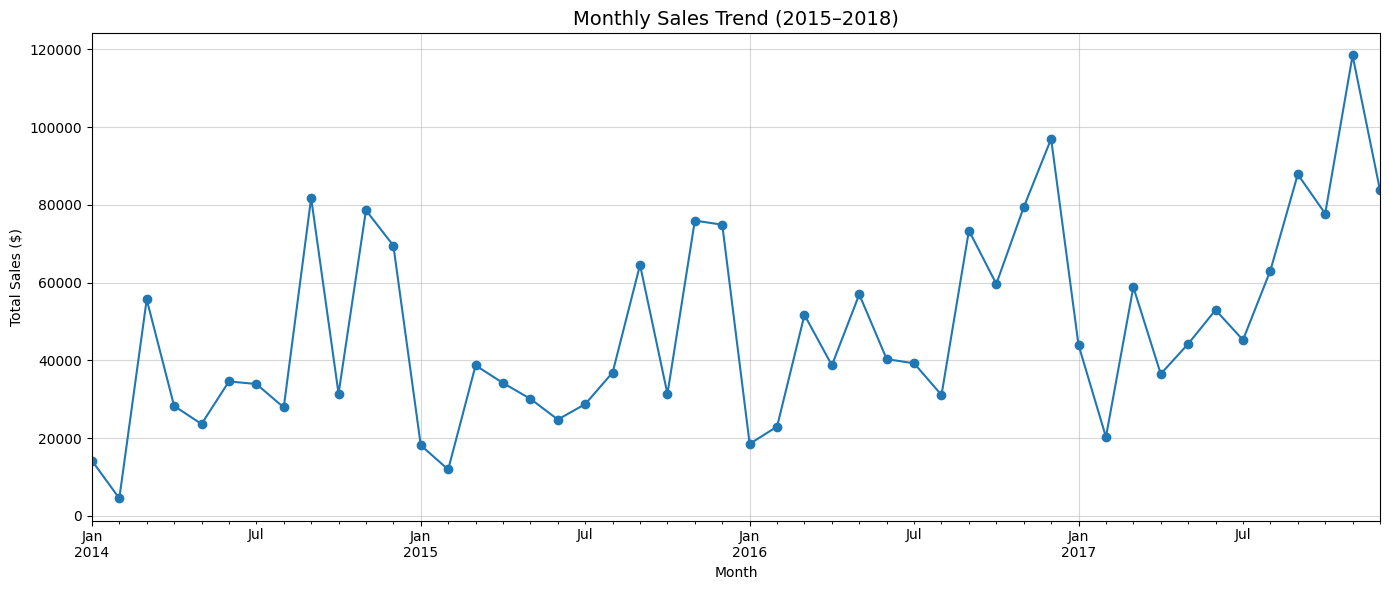

In [9]:
import matplotlib.pyplot as plt


monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()


plt.figure(figsize=(14, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend (2015–2018)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150)

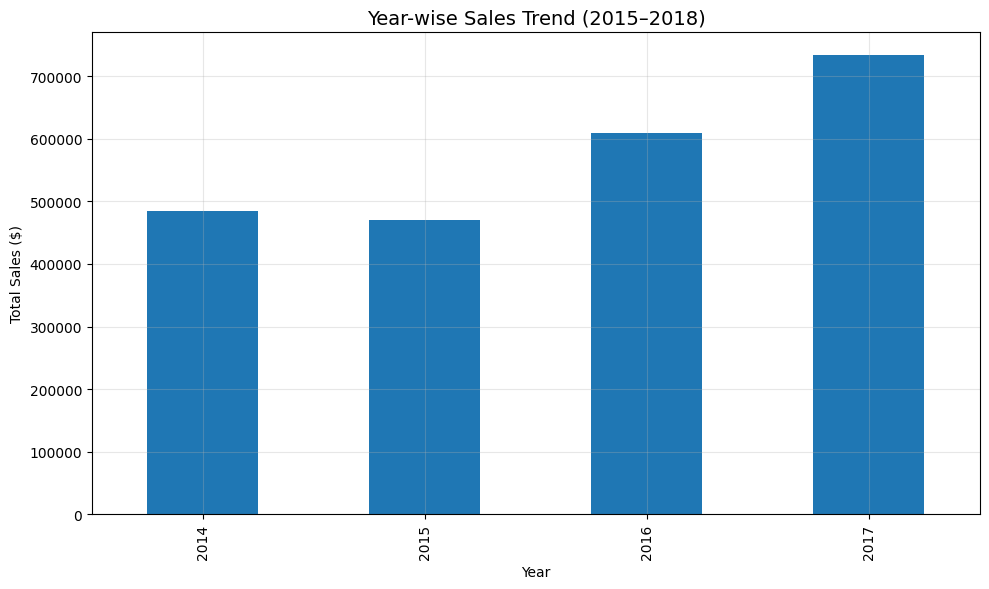

In [10]:
import matplotlib.pyplot as plt


yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum()

plt.figure(figsize=(10, 6))
yearly_sales.plot(kind='bar')

plt.title('Year-wise Sales Trend (2015–2018)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig('yearly_sales_trend.png', dpi=150)
plt.show()


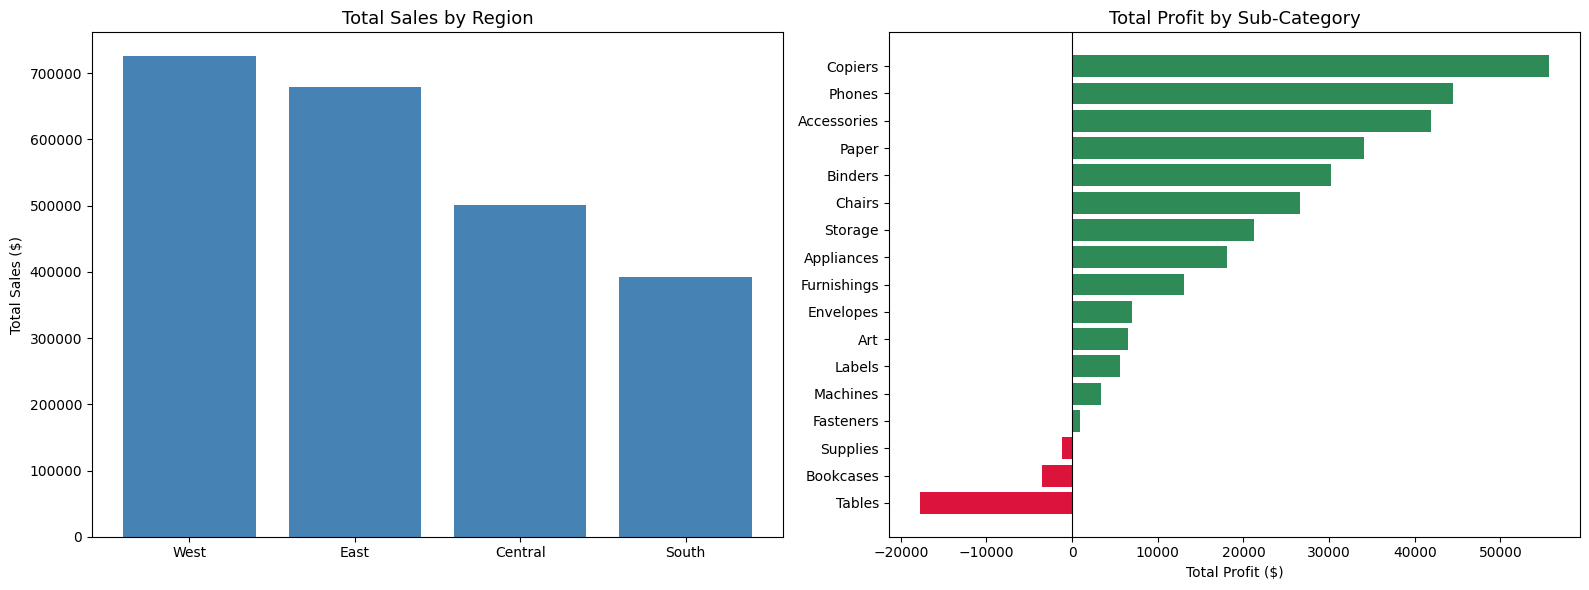

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[0].bar(region_sales.index, region_sales.values, color='steelblue')
axes[0].set_title('Total Sales by Region', fontsize=13)
axes[0].set_ylabel('Total Sales ($)')


subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['crimson' if x < 0 else 'seagreen' for x in subcat_profit.values]
axes[1].barh(subcat_profit.index, subcat_profit.values, color=colors)
axes[1].set_title('Total Profit by Sub-Category', fontsize=13)
axes[1].set_xlabel('Total Profit ($)')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('category_region_performance.png', dpi=150)
plt.show()

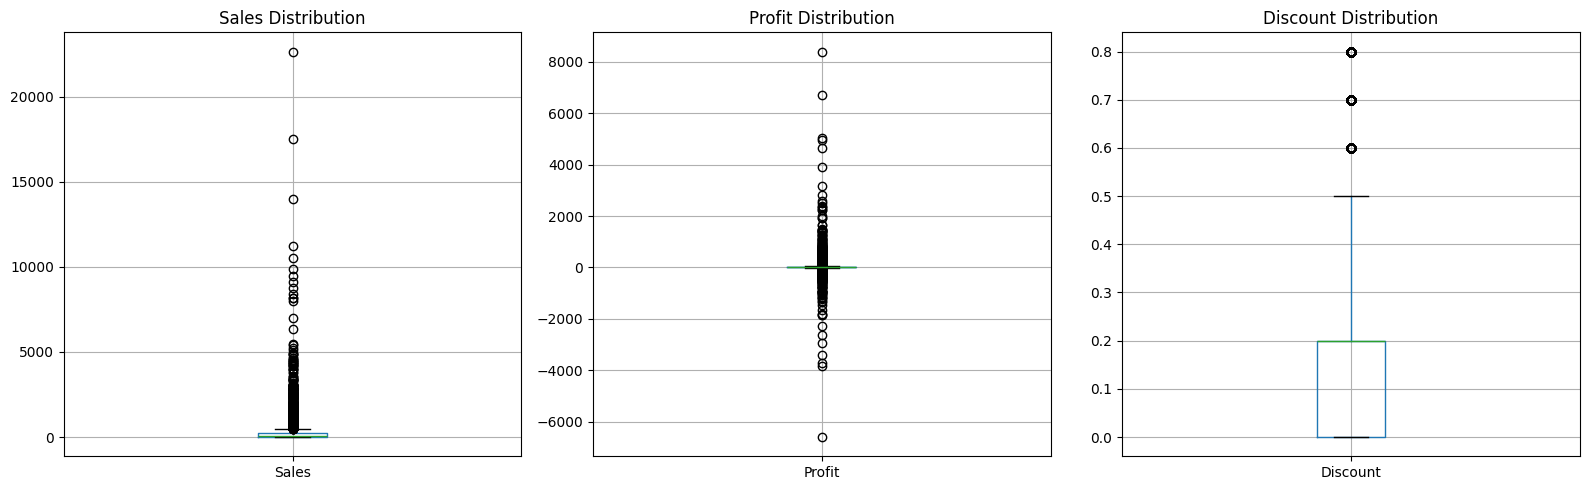

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.boxplot(column='Sales', ax=axes[0])
axes[0].set_title('Sales Distribution')

df.boxplot(column='Profit', ax=axes[1])
axes[1].set_title('Profit Distribution')

df.boxplot(column='Discount', ax=axes[2])
axes[2].set_title('Discount Distribution')

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=150)
plt.show()

In [13]:
high_discount = df[df['Discount'] >= 0.5]
print(high_discount['Category'].value_counts())
print("\n")
print(high_discount['Sub-Category'].value_counts())

Category
Office Supplies    680
Furniture          207
Technology          35
Name: count, dtype: int64


Sub-Category
Binders        613
Furnishings    138
Appliances      67
Tables          36
Machines        35
Bookcases       33
Name: count, dtype: int64


In [14]:
loss_makers = df[df['Sub-Category'].isin(['Tables', 'Bookcases'])]

summary = loss_makers.groupby('Sub-Category').agg(
    Avg_Discount=('Discount', 'mean'),
    Avg_Profit_Margin=('Profit', lambda x: x.sum() / loss_makers.loc[x.index, 'Sales'].sum() * 100),
    Total_Orders=('Order ID', 'count'),
    Orders_With_Discount=('Discount', lambda x: (x > 0).sum())
).round(2)

print(summary)

              Avg_Discount  Avg_Profit_Margin  Total_Orders  \
Sub-Category                                                  
Bookcases             0.21              -3.02           228   
Tables                0.26              -8.56           319   

              Orders_With_Discount  
Sub-Category                        
Bookcases                      168  
Tables                         247  


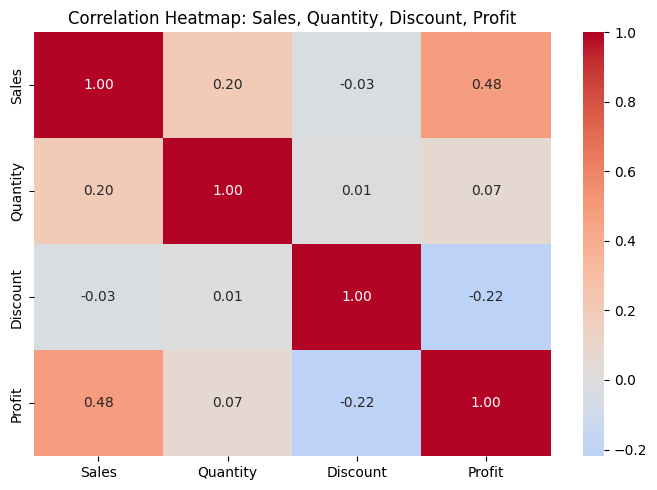

In [15]:
import seaborn as sns

corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: Sales, Quantity, Discount, Profit')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [20]:
from google.colab import files
files.download('monthly_sales_trend.png')
files.download('category_region_performance.png')
files.download('outlier_detection.png')
files.download('correlation_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')